In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [14]:
class QUADState(TypedDict):

    a : int
    b : int
    c : int
    equation : str
    discriminant : float
    result  : str


In [15]:
def show_equation(state: QUADState) -> QUADState:
    
    equation = f"{state['a']}x2{state['b']}x{state['c']}"

    return {'equation':equation}

def calculate_discriminant(state: QUADState) -> QUADState:
    
    discriminant = state['b']**2- (4*state['a']*state['c'])

    return {'discriminant':discriminant}

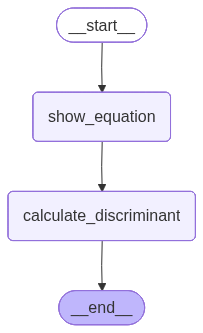

In [16]:
graph  = StateGraph(QUADState)

# adding nodes
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)


# Adding Edge
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_edge('calculate_discriminant',END)

# compiling graph
workflow = graph.compile()

workflow


In [17]:
# graph execution

initial_state = {'a':4,'b':-5,'c':-4}

workflow.invoke(initial_state)


{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2-5x-4', 'discriminant': 89}

In [18]:
class QUADState(TypedDict):

    a : int
    b : int
    c : int
    equation : str
    discriminant : float
    result  : str


In [19]:
def show_equation(state: QUADState) -> QUADState:
    
    equation = f"{state['a']}x2{state['b']}x{state['c']}"

    return {'equation':equation}

def calculate_discriminant(state: QUADState) -> QUADState:
    
    discriminant = state['b']**2- (4*state['a']*state['c'])

    return {'discriminant':discriminant}

In [20]:
from typing import Literal


def real_roots(state : QUADState):

    root1 = (-state['b'] + state['discriminant']**0.5)/2*state['a']
    root2 = (-state['b'] - state['discriminant']**0.5)/2*state['a']

    result = f"The result are {root1} and {root2}"

    return {'result': result}

def repeated_roots(state : QUADState):

    root1 = ((-state['b'])/2*state['a'])

    result = f"Only repeating roots is {root1}"

    return {'result': result}

def no_real_roots(state : QUADState):

    result = f" No Real Roots"

    return {'result': result}

def check_condition(state: QUADState) -> Literal["real_roots","no_real_roots","repeated_roots"]:

    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

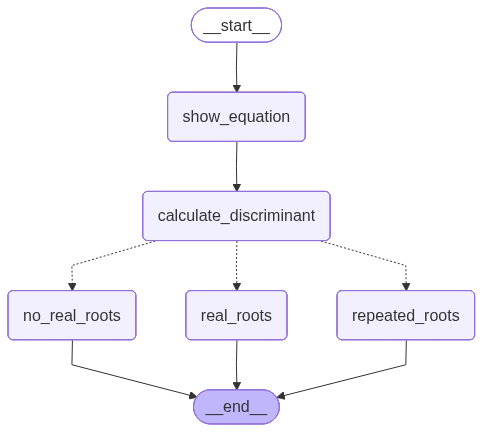

In [21]:
graph  = StateGraph(QUADState)

# adding nodes
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


# Adding Edge
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('no_real_roots',END)
graph.add_edge('repeated_roots',END)

# compiling graph
workflow = graph.compile()

workflow


In [22]:
# graph execution

initial_state = {'a':4,'b':-5,'c':-4}

workflow.invoke(initial_state)


{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2-5x-4',
 'discriminant': 89,
 'result': 'The result are 28.867962264113206 and -8.867962264113206'}

In [23]:
# graph execution

initial_state = {'a':4,'b':2,'c':4}

workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x22x4',
 'discriminant': -60,
 'result': ' No Real Roots'}